In [9]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import math,random,os,sys, importlib, time
from matplotlib.colors import ListedColormap, BoundaryNorm

ROOT = Path.cwd().resolve().parents[0]
SRC  = ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
import data.sample_x as sample_x_mod; importlib.reload(sample_x_mod)
import data.solve_ode as solve_ode_mod; importlib.reload(solve_ode_mod)
import data.utils as utils_mod; importlib.reload(utils_mod)

from data.sample_x import sample_x
from data.solve_ode import SpringParams, simulate_spring
import data.utils as utils; importlib.reload(utils)
from data.utils import plot_traj, check_safety,compute_x_safety_map, compute_mu_safety_map,compute_cov_safety_map

import data.plotting as plotting
importlib.reload(plotting)
from data.plotting import plot_x_safety_map, plot_mu_safety_map,annotate_mu_shift_directions

import pickle, pathlib


(10000, 2)
Empirical safety probability: 0.9211
Chance constraint threshold (1-eta) = 0.9000 -> config_safety = 1


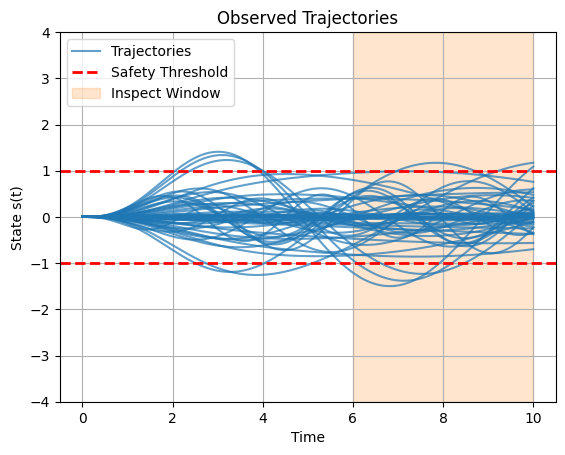

In [2]:

z_0 = np.array([0.0, 0.0])  # baseline configuration
params = SpringParams(mass=1.0, damping=1, stiffness=2.0) # system parameters

mean = np.array([0,0]); cov = np.diag([1, 1]) # parameters of the X distribution


tau = 1 # safety upper threshold for trajectory
T = 10; dt = 0.01 # t \in [0,T] with step dt = 0.01
time_window = (6, 10) # inspection window
seed = 1 # random seed


# X = sample_x(n_samples = 10000, dist_type="gaussian", params={"mean": mean, "cov": cov}, seed=seed)

#### a bounded box 
low, high = -3.0, 3.0
X = sample_x(n_samples = 10000, dist_type="gaussian", params={"mean": mean, "cov": cov}, seed=seed,truncate_box=(low,high))
print(X.shape)

###### return a dict with keys: dict_keys(['t', 's', 's_dot']), time (T array), position (n * T array), velocity (n * T array)
traj = simulate_spring(params, t_final=T, dt=dt, X=X, forcing_type='sin', config=z_0)

### in real data only observe X and traj['s], traj['s_dot]
# Check whether current configuration is safe under baseline N(mean, cov)
# safety_indicator = 1 if safe, 0 if unsafe
eta = 0.1
safety_indicator = check_safety(traj, threshold=tau, window=time_window)

p_safe = float(np.mean(safety_indicator))
print(f"Empirical safety probability: {p_safe:.4f}")

config_safety = 1 if p_safe >= 1.0 - eta else 0  # chance constraint
print(f"Chance constraint threshold (1-eta) = {1.0 - eta:.4f} -> config_safety = {config_safety}")
plot_traj(traj, threshold=tau, window=time_window,n_max=50,title='Observed Trajectories',ylim=(-4,4))


In [325]:
res_mu_safety = compute_mu_safety_map(params, t_final=T, dt=dt,
    window=time_window,
    threshold=tau,
    cov=cov,
    n_mu_grid=21,
    mu_limits= (-1.0, 1.0),
    n_per_mu = 10000,
    forcing_type="sin",
    config=z_0,
    eta = eta,
    truncate_X_box=(low,high),
    batch_size=2000,
    seed=0)

KeyboardInterrupt: 

In [ ]:
# save
out_path = ROOT / "cache" / f"res_mu_safety_tau_{tau}_eta_{eta}.pkl"
out_path.parent.mkdir(parents=True, exist_ok=True)
with out_path.open("wb") as f:
    pickle.dump(res_mu_safety, f)

    

In [3]:
# load 
out_path = ROOT / "cache" / f"res_mu_safety_tau_{tau}_eta_{eta}.pkl"
with out_path.open("rb") as f:
    res_mu_safety = pickle.load(f)

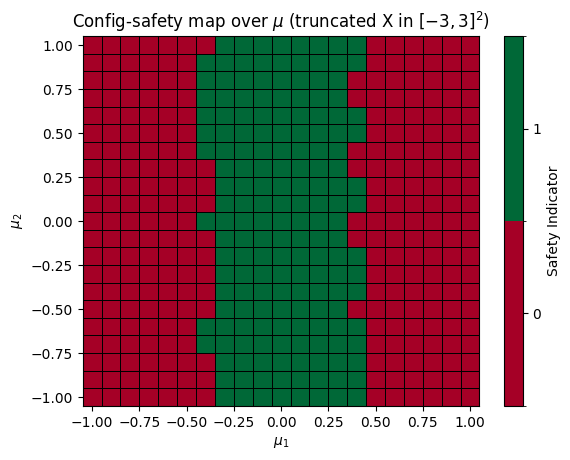

In [ ]:
# Plot indicator (0/1 per mu cell) with visible cell boundaries
from matplotlib.colors import ListedColormap, BoundaryNorm

cmap_indicator = ListedColormap(["#a50026", "#006837"])   # gray, muted green
norm_indicator = BoundaryNorm([-0.5, 0.5, 1.5], cmap_indicator.N)

plot_mu_safety_map(
    res_mu_safety,
    mode="indicator",
    title=r"Config-safety map over $\mu$ (truncated X in $[-3,3]^2$)",
    cmap=cmap_indicator,
    norm=norm_indicator,
    show_cell_edges=True,
    linewidth=0.5,
    draw_boundary=False,
)

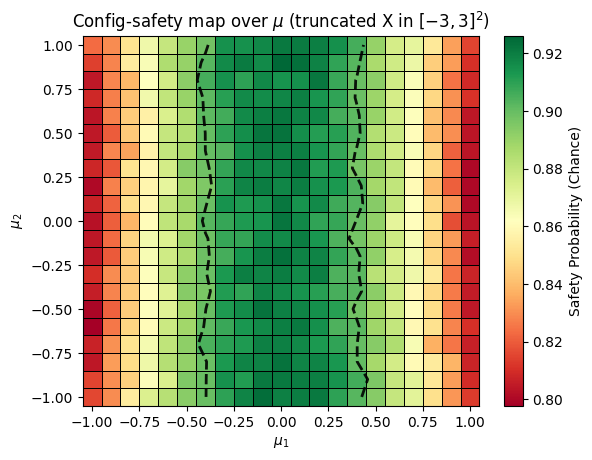

In [ ]:
fig,ax= plot_mu_safety_map(
    res_mu_safety,
    mode="prob",
    title=r"Config-safety map over $\mu$ (truncated X in $[-3,3]^2$)",
    cmap="RdYlGn",
    show_cell_edges=True,
    linewidth=0.5,
    boundary_lw=2,
    boundary_color='black',
    draw_boundary=True,
    vmax=res_mu_safety['safe'].max(),
    vmin=res_mu_safety['safe'].min(),
    eta=0.1
)

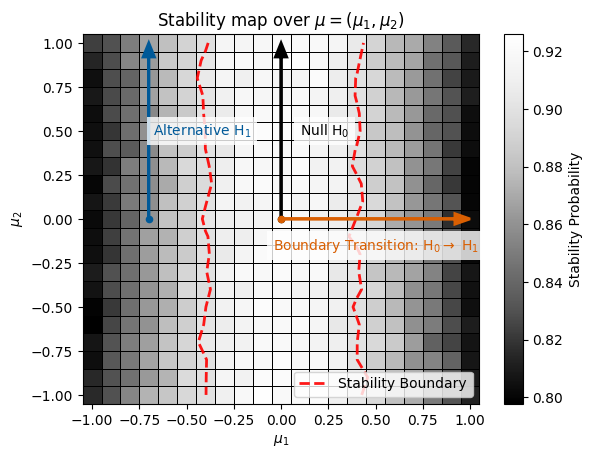

In [360]:
import data.plotting as plotting
importlib.reload(plotting)
from data.plotting import plot_x_safety_map, plot_mu_safety_map,annotate_mu_shift_directions,annotate_x_shift_directions,plot_x_safety_map_shift_panels

# Plot indicator (0/1 per mu cell) with visible cell boundaries
fig,ax= plot_mu_safety_map(
    res_mu_safety,
    mode="prob",
   #  title=r"Config-safety map over $\mu$ (truncated X in $[-3,3]^2$)",
   title=r"Stability map over $\mu=(\mu_1, \mu_2)$",
    cmap="Greys_r",
    show_cell_edges=True,
    linewidth=0.5,
    boundary_lw=2,
    boundary_color='red',
    draw_boundary=True,
    vmax=res_mu_safety['safe'].max(),
    vmin=res_mu_safety['safe'].min(),
    eta=0.1
)

annotate_mu_shift_directions(
    ax,
    initial_positions=[(0, 0), (0, 0), (-0.7, 0)],
    directions=[(0, 1), (1, 0), (0, 1)],
    labels=[r"Null H$_0$", r"Boundary Transition: H$_0 \to$ H$_1$", r"Alternative H$_1$"],
    arrow_scale=1,
    colors = ["black", "#d95f02", "#005998"],
    # arrow_scale_each=[0.25, 0.25, 0.25],
    text_side=["right", "bottom", "right"],
    text_offset_each=[(0.1, 0.0), (0.0, 0.1), (0.02, 0.00)],
)
plt.show()

In [ ]:

res_x_safety = compute_x_safety_map(params, t_final=T, dt=dt, window=time_window,
                           threshold=tau, n_grid=300, box_limits=(-3,3),
                           forcing_type="sin", config=z_0)
# save
out_path = ROOT / "cache" / f"res_x_safety_tau_{tau}_eta_{eta}.pkl"
out_path.parent.mkdir(parents=True, exist_ok=True)
with out_path.open("wb") as f:
    pickle.dump(res_x_safety, f)


In [5]:
#  load 
out_path = ROOT / "cache" / f"res_x_safety_tau_{tau}_eta_{eta}.pkl"
with out_path.open("rb") as f:
    res_x_safety = pickle.load(f)

Empirical safety probability=0.9198 vs threshold 0.9000 (eta=0.1000) -> SAFE


(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'Safety map in X box'}, xlabel='A', ylabel='omega'>)

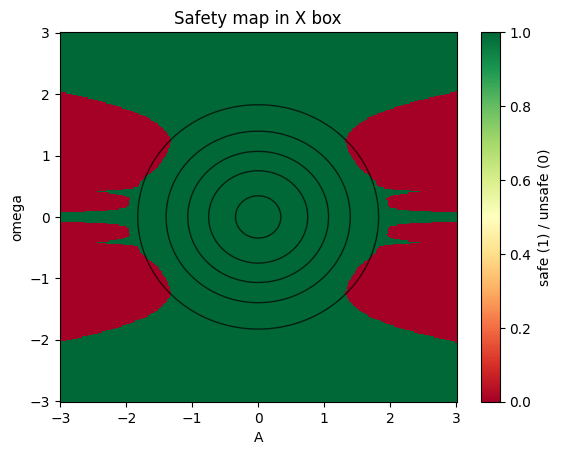

In [6]:
mean_test = np.array([0.,0])
cov_test = np.diag([1, 1])
plot_x_safety_map(res_x_safety, mean=mean_test, cov=cov_test,
                  contour_levels=5, contour_color="black",
                  contour_alpha=0.7, eta=0.1, print_msg=True,
                  contour_mass=False, contour_mass_max=0.9,)  


Empirical safety probability=0.9198 vs threshold 0.9000 (eta=0.1000) -> SAFE


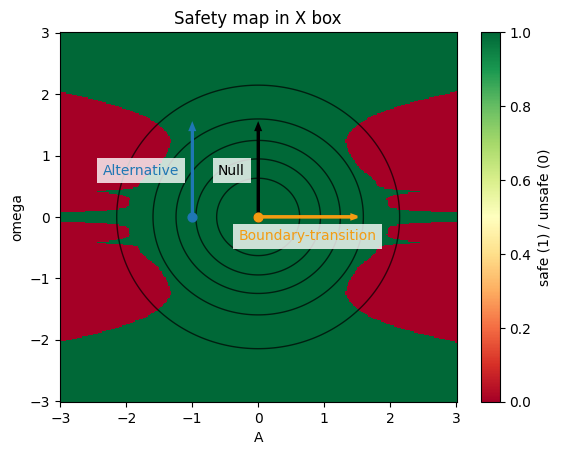

In [ ]:
fig, ax = plot_x_safety_map(
    res_x_safety,
    mean=mean_test,
    cov=cov_test,
    contour_levels=5,
    contour_mass=True,
    contour_mass_max=0.9,
    contour_color="black",
    contour_alpha=0.7,
    eta=0.1,
    print_msg=True,
)

annotate_x_shift_directions(
    ax,
    initial_positions=[(0, 0), (0, 0), (-1, 0)],
    directions=[(0, 1), (1, 0), (0, 1)],
    labels=["Null", "Boundary-transition", "Alternative"],
    arrow_scale=1.5,
    horizontal_text_position='bottom',
    vertical_text_position = 'left',
    text_pad = 0.2
)

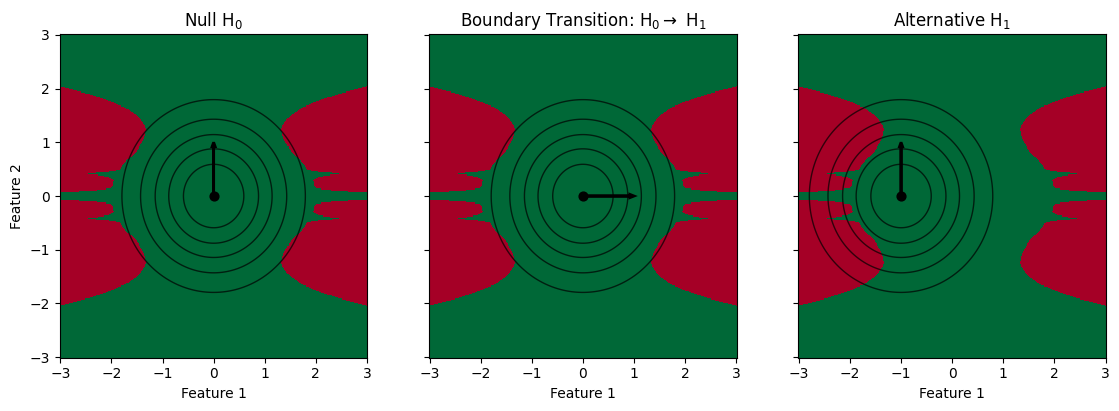

In [ ]:
import data.plotting as plotting
importlib.reload(plotting)
from data.plotting import plot_x_safety_map, plot_mu_safety_map,annotate_mu_shift_directions,annotate_x_shift_directions,plot_x_safety_map_shift_panels

cmap_indicator = ListedColormap(["#a50026", "#006837"])   # gray, muted green
norm_indicator = BoundaryNorm([-0.5, 0.5, 1.5], cmap_indicator.N)

fig, axes = plot_x_safety_map_shift_panels(
    res_x_safety,
    initial_positions=[(0, 0), (0, 0), (-1, 0)],
    directions=[(0, 1), (1, 0), (0, 1)],
    labels=[r"Null H$_0$", r"Boundary Transition: H$_0 \to$ H$_1$", r"Alternative H$_1$"],
    # labels=["Null H_0", "Boundary-transition H0 to H1", "Alternative H1"],
    colors = ["black", "black", "black"],
    cmap=cmap_indicator,
    norm=norm_indicator,
    mean=mean_test,
    cov=cov_test,
    contour_levels=5,
    contour_mass=True,
    contour_mass_max=0.8,
    contour_color="black",
    contour_alpha=0.7,
    arrow_scale=1,
    horizontal_text_position="bottom",
    vertical_text_position="left",
    text_pad=0.2,show_arrow_text=False,
    
)


In [338]:
! pwd

/home/mzheng/research/Physics-Informed-Hypo-Test/notebook


In [342]:
from pathlib import Path

out_path = Path("../experiment/results/figure/spring_mu_shift_panels_test.png")
fig.savefig(out_path, dpi=fig.dpi)


In [335]:
! ls

''$'\r''esults'$'\f''igure\spring_mu_shift_panels.png'
 archive
 cartesian_pendulum_example.ipynb
 figure
 plot_frame_strcuture.ipynb
'spring_example copy.ipynb'
 spring_example.ipynb
 spring_model_demo.ipynb
 toy_outputs


In [333]:
print("size_inches:", fig.get_size_inches())
print("dpi:", fig.dpi)
print("pixel_size:", fig.get_size_inches() * fig.dpi)


size_inches: [13.5  4.2]
dpi: 100.0
pixel_size: [1350.  420.]


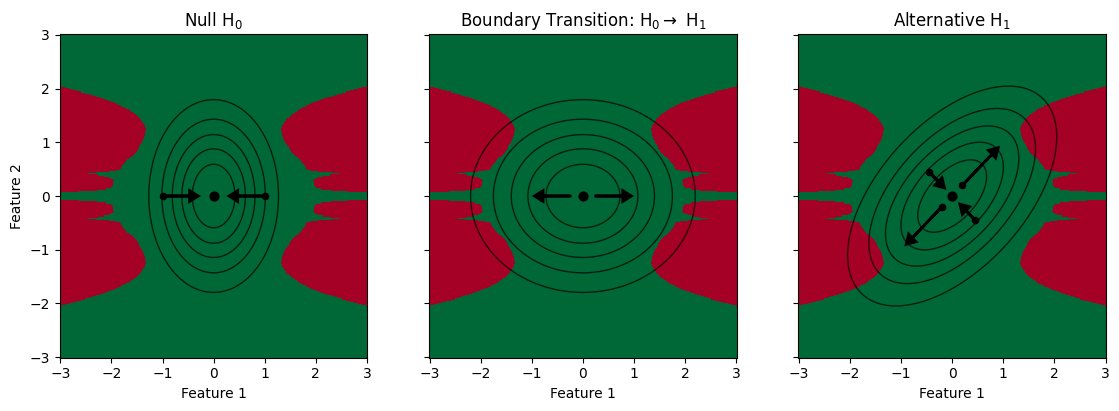

In [15]:
import data.plotting as plotting; importlib.reload(plotting)
from data.plotting import plot_cov_safety_map,plot_x_safety_map_cov_panels_no_bar,annotate_covariance_change, plot_x_safety_map, plot_mu_safety_map,annotate_mu_shift_directions,annotate_x_shift_directions,plot_x_safety_map_shift_panels, plot_x_safety_map_cov_panels


cmap_indicator = ListedColormap(["#a50026", "#006837"])
norm_indicator = BoundaryNorm([-0.5, 0.5, 1.5], cmap_indicator.N)

mean_test = np.array([0.0, 0.0])

cov_scale_down = np.diag([0.5, 1])
cov_scale_up = np.diag([1.5, 1])
cov_corr = np.array([
    [1.3, 0.7],
    [0.7, 1.3],
])


fig, axes = plot_x_safety_map_cov_panels_no_bar(
    res_x_safety,
    covariances=[cov_scale_down, cov_scale_up,cov_corr],
    # labels=["variance decrease", "variance increase", r"correlation change"],
    labels=[r"Null H$_0$", r"Boundary Transition: H$_0 \to$ H$_1$", r"Alternative H$_1$"],
    mean=(0.0, 0.0),
    cmap=cmap_indicator,
    norm=norm_indicator,
    contour_levels=5,
    contour_mass=True,
    contour_mass_max=0.8,
    contour_color="black",
    contour_alpha=0.7,
    reference_cov=np.diag([1.0, 1.0]),
    show_reference=False,
)
annotate_mu_shift_directions(
    axes[0],
    initial_positions=[(1, 0.0), (-1, 0.0)],
    directions=[(-1.0, 0.0), (1.0, 0.0)],
    labels=["", ""],
    arrow_scale=0.7,
    arrow_start_pad=0.,
    colors=["black", "black"],
    arrow_head_width=0.2,
    arrow_head_length=0.17,
    # arrow_start_pad_each =[0.32, 0.32]

)

annotate_mu_shift_directions(
    axes[1],
    initial_positions=[(0.0, 0.0), (0.0, 0.0)],
    directions=[(1.0, 0.0), (-1.0, 0.0)],
    labels=["", ""],
    arrow_scale=.7,
    arrow_start_pad=0.25,
    colors=["black", "black"],
    arrow_head_width=0.2,
    arrow_head_length=0.17,
)
annotate_mu_shift_directions(
    axes[2],
    initial_positions=[(0.2, 0.2), (-0.2, -0.2), (0.45, -0.45), (-0.45, 0.45)],
    directions=[(1.0, 1.0), (-1.0, -1.0), (-1.0, 1.0), (1.0, -1.0)],
    labels=["", "", "", ""],
    arrow_scale_each=[0.7, 0.7, 0.3, 0.3],
    arrow_start_pad_each=[0,0,0,0],
    colors=["black", "black", "black", "black"],
    arrow_head_width=0.2,
    arrow_head_length=0.17,
)
# annotate_covariance_change(axes[0], mean=(0.0, 0.0), mode="scale_down", color="black", scale=0.8)
# annotate_covariance_change(axes[1], mean=(0.0, 0.0), mode="scale_up", color="black", scale=0.8,origin_pad=0.3)
# annotate_covariance_change(axes[2], mean=(0.0, 0.0), mode="correlation", color="black", scale=1,origin_pad=0.3)

/home/mzheng/research/Physics-Informed-Hypo-Test/src/data/plotting.py:880: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, subplot_right, 1])


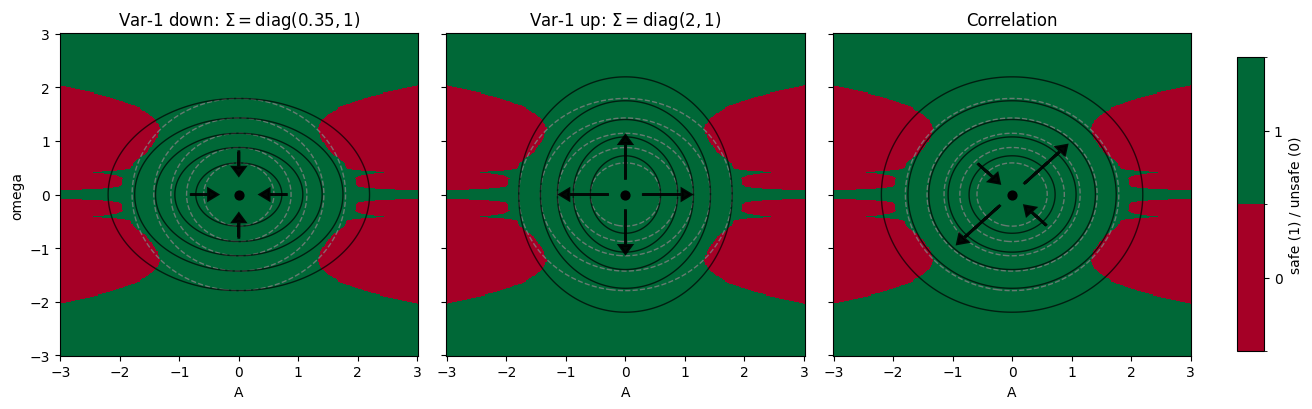

In [ ]:
# cov_var1_down = np.array([
#     [1.5, 0.0],
#     [0.0, 1.0],
# ])

# cov_var1_up = np.array([
#     [1.0, 0.0],
#     [0.0, 1.5],
# ])

# cov_corr = np.array([
#     [1.5, 0.0],
#     [0.0, 1.5],
# ])
# cov_anisotropic = np.array([
#     [1.6, 0.0],
#     [0.0, 0.5],
# ])

# fig, axes = plot_x_safety_map_cov_panels(
#     res_x_safety,
#     covariances=[cov_var1_down, cov_var1_up, cov_corr],
#     labels=[
#         r"Var-1 down: $\Sigma=\mathrm{diag}(0.35,1)$",
#         r"Var-1 up: $\Sigma=\mathrm{diag}(2,1)$",
#         r"Correlation",
#     ],
#     mean=(0.0, 0.0),
#     cmap=cmap_indicator,
#     norm=norm_indicator,
#     contour_levels=5,
#     contour_mass=True,
#     contour_mass_max=0.8,
#     contour_color="black",
#     contour_alpha=0.7,
#     reference_cov=np.diag([1.0, 1.0]),
# )

# annotate_covariance_change(axes[0], mean=(0.0, 0.0), mode="scale_down", color="black", scale=0.8)
# annotate_covariance_change(axes[1], mean=(0.0, 0.0), mode="scale_up", color="black", scale=0.8,origin_pad=0.3)
# annotate_covariance_change(axes[2], mean=(0.0, 0.0), mode="correlation", color="black", scale=1,origin_pad=0.3)

In [ ]:
res_cov_safety = compute_cov_safety_map(
    params,
    t_final=T,
    dt=dt,
    window=time_window,
    threshold=tau,
    mean=np.array([0.0, 0.0]),
    n_cov_grid=21,
    delta1_limits=(0.5, 1.5),
    delta2_limits=(-0.5, 0.5),
    n_per_cov=20000,
    forcing_type="sin",
    config=z_0,
    eta=eta,
    truncate_X_box=(low, high),
    batch_size=2000,
    seed=1,
)


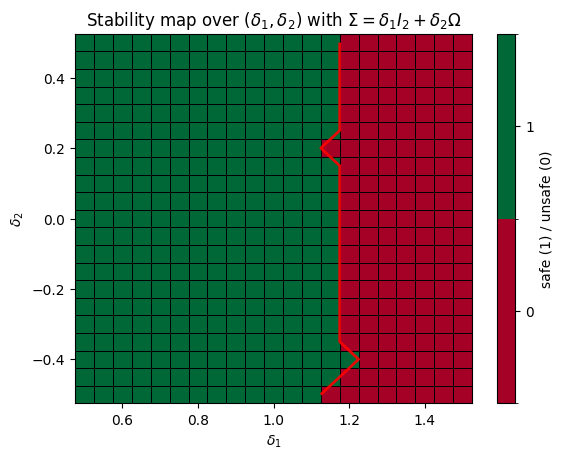

In [ ]:
cmap_indicator = ListedColormap(["#a50026", "#006837"])   # gray, muted green
norm_indicator = BoundaryNorm([-0.5, 0.5, 1.5], cmap_indicator.N)

fig, ax = plot_cov_safety_map(
    res_cov_safety,
    mode="indicator",
    title=(
        r"Stability map over $(\delta_1,\delta_2)$" " with "
        r"$\Sigma=\delta_1 I_2+\delta_2\Omega$"
    ),
    cmap=cmap_indicator,
    norm=norm_indicator,
    show_cell_edges=True,
    linewidth=0.5,
    boundary_lw=2,
    boundary_color="red",
    draw_boundary=True,
    vmax=res_cov_safety["safe"].max(),
    vmin=res_cov_safety["safe"].min(),
    eta=0.1,
)
plt.show()


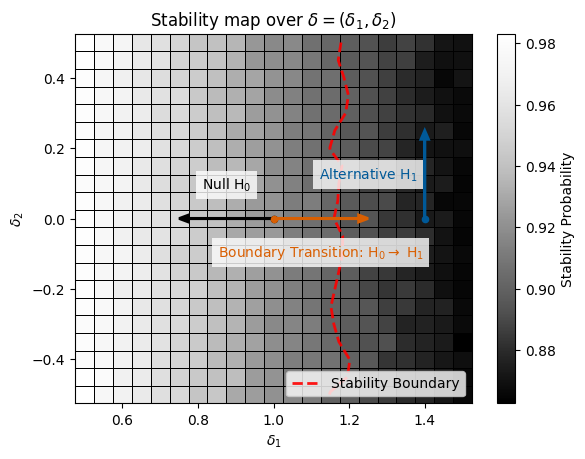

In [361]:
import data.plotting as plotting
importlib.reload(plotting)
from data.plotting import annotate_mu_shift_directions,plot_cov_safety_map

fig, ax = plot_cov_safety_map(
    res_cov_safety,
    mode="prob",
    title=(
        r"Stability map over $\delta= (\delta_1,\delta_2)$"
    ),
    cmap='Greys_r',
    # norm=norm_indicator,
    show_cell_edges=True,
    linewidth=0.5,
    boundary_lw=2,
    boundary_color="red",
    draw_boundary=True,
    vmax=res_cov_safety["safe"].max(),
    vmin=res_cov_safety["safe"].min(),
    eta=0.1,
)
annotate_mu_shift_directions(
    ax,
    initial_positions=[(1.0, 0.0), (1.0, 0.0), (1.4, 0.0)],
    directions=[(-1.0, 0.0), (1, 0), (0.0, 1.0)],
    labels=[r"Null H$_0$", r"Boundary Transition: H$_0 \to$ H$_1$", r"Alternative H$_1$"],
    arrow_scale_each=[0.25, 0.25, 0.25],
    text_side=["top", "bottom", "left"],
    text_offset_each=[(0.03, 0.07), (0.03, 0.07), (0.02, 0.00)],
    colors=["black", "#d95f02", "#005998"],
    arrow_head_width=0.02,
    arrow_head_length=0.025,
)
plt.show()
